# Consolidated Color vs Teff Analysis for F, G, K, M Dwarfs

This notebook provides a unified analysis of the color-temperature relationships across multiple spectral types (F, G, K, M). It generates large-scale contour plots showing the density of stars in various color spaces relative to their effective temperature ($T_{eff}$).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_context("talk")
sns.set_palette("husl")

# Define paths
DATA_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results')
RESULTS_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results\consolidated_analysis')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Phase 1: Data Loading (Sanity Check)

We will load datasets for F, G, K, and M dwarfs and combine them.

In [2]:
def load_consolidated_data(data_dir):
    spectral_types = ['F', 'G', 'K', 'M']
    dfs = []
    
    for stype in spectral_types:
        file_path = data_dir / f'Xmatch_gaia_LAMOST_LAMOSTvac_{stype}_dwarfs_clean.csv'
        if file_path.exists():
            temp_df = pd.read_csv(file_path)
            temp_df['spectral_type_group'] = stype
            dfs.append(temp_df)
            print(f"Loaded {stype} dwarf data: {len(temp_df)} rows")
        else:
            print(f"Warning: {file_path} not found.")
    
    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"\nTotal combined rows: {len(combined_df)}")
    return combined_df

# Initial load (Sanity Check 1)
df = load_consolidated_data(DATA_DIR)

print(f"Teff range: {df['teff'].min():.0f} K to {df['teff'].max():.0f} K")

Loaded F dwarf data: 308305 rows
Loaded G dwarf data: 929378 rows
Loaded K dwarf data: 173286 rows
Loaded M dwarf data: 35267 rows

Total combined rows: 1446236
Teff range: 3114 K to 8435 K


In [3]:
# Filter for rows where the 'obsid' appears more than once
overlap_mask = df.duplicated(subset=['obsid'], keep=False)
overlapping_stars_df = df[overlap_mask].sort_values(by=['obsid', 'spectral_type_group'])

# summary table of the overlaps
if not overlapping_stars_df.empty:
    # Group by obsid to find which spectral types each star belongs to
    star_overlap_types = overlapping_stars_df.groupby('obsid')['spectral_type_group'].apply(lambda x: ' & '.join(sorted(x.unique())))
    
    overlap_summary = star_overlap_types.value_counts().reset_index()
    overlap_summary.columns = ['Spectral Type Combination', 'Star Count']
    
    print("\n=== Overlap Summary Table ===")
    display(overlap_summary)
    
    print(f"\nTotal overlapping rows: {len(overlapping_stars_df)}")
    print(f"Total unique overlapping stars: {len(star_overlap_types)}")
    
    print("\n=== DataFrame of Overlapping Stars (First 5 rows) ===")
    display(overlapping_stars_df.head())
else:
    print("No overlapping stars found based on 'obsid'.")


=== Overlap Summary Table ===


,Spectral Type Combination,Star Count
0,F & G,292377
1,G & K,140873



Total overlapping rows: 866500
Total unique overlapping stars: 433250

=== DataFrame of Overlapping Stars (First 5 rows) ===


,obsid,subclass,gaia_source_id,distance_gaia_pc,mag_ps_g,mag_ps_r,mag_ps_i,mag_ps_z,mag_ps_y,teff,...,COLOR_APASS_B_V,COLOR_APASS_V_R,COLOR_SDSS_G_R,COLOR_SDSS_R_I,COLOR_X_GAIA_PS,COLOR_X_PS_2MASS,COLOR_X_2MASS_WISE,COLOR_X_APASS_SDSS,COLOR_X_SDSS_GAIA,spectral_type_group
875403,101179,NaN,2676118053972560256,445.011621,16.069000,15.0910,14.7009,14.5158,14.3977,4373.41,...,0.706420,0.421061,0.838449,0.803761,-9.301040,9.353627,0.103396,0.040148,0.035061,G
1349862,101179,K5,2676118053972560256,445.011621,16.069000,15.0910,14.7009,14.5158,14.3977,4373.41,...,0.706420,0.421061,0.838449,0.803761,-9.301040,9.353627,0.103396,0.040148,0.035061,K
902123,102002,NaN,2677134896069602688,599.234849,16.657101,15.6666,15.2651,15.0944,14.9638,4420.36,...,1.461409,-0.000806,0.998390,1.122321,-10.187649,9.970004,0.367203,0.053627,-0.355933,G
1346682,102002,K5,2677134896069602688,599.234849,16.657101,15.6666,15.2651,15.0944,14.9638,4420.36,...,1.461409,-0.000806,0.998390,1.122321,-10.187649,9.970004,0.367203,0.053627,-0.355933,K
902314,102015,NaN,2677121014735284352,699.776964,16.676800,15.7918,15.4387,15.2887,15.1608,4604.32,...,0.375566,0.574558,1.106946,0.485713,-10.589403,10.514450,0.035136,-0.533863,0.208346,G


In [17]:
overlapping_stars_df.head(30)

,obsid,subclass,gaia_source_id,distance_gaia_pc,mag_ps_g,mag_ps_r,mag_ps_i,mag_ps_z,mag_ps_y,teff,...,COLOR_APASS_B_V,COLOR_APASS_V_R,COLOR_SDSS_G_R,COLOR_SDSS_R_I,COLOR_X_GAIA_PS,COLOR_X_PS_2MASS,COLOR_X_2MASS_WISE,COLOR_X_APASS_SDSS,COLOR_X_SDSS_GAIA,spectral_type_group
875403,101179,NaN,2676118053972560256,445.011621,16.069000,15.0910,14.700900,14.5158,14.397700,4373.41,...,0.706420,0.421061,0.838449,0.803761,-9.301040,9.353627,0.103396,0.040148,0.035061,G
1349862,101179,K5,2676118053972560256,445.011621,16.069000,15.0910,14.700900,14.5158,14.397700,4373.41,...,0.706420,0.421061,0.838449,0.803761,-9.301040,9.353627,0.103396,0.040148,0.035061,K
902123,102002,NaN,2677134896069602688,599.234849,16.657101,15.6666,15.265100,15.0944,14.963800,4420.36,...,1.461409,-0.000806,0.998390,1.122321,-10.187649,9.970004,0.367203,0.053627,-0.355933,G
1346682,102002,K5,2677134896069602688,599.234849,16.657101,15.6666,15.265100,15.0944,14.963800,4420.36,...,1.461409,-0.000806,0.998390,1.122321,-10.187649,9.970004,0.367203,0.053627,-0.355933,K
902314,102015,NaN,2677121014735284352,699.776964,16.676800,15.7918,15.438700,15.2887,15.160800,4604.32,...,0.375566,0.574558,1.106946,0.485713,-10.589403,10.514450,0.035136,-0.533863,0.208346,G
1354185,102015,K5,2677121014735284352,699.776964,16.676800,15.7918,15.438700,15.2887,15.160800,4604.32,...,0.375566,0.574558,1.106946,0.485713,-10.589403,10.514450,0.035136,-0.533863,0.208346,K
901954,102103,NaN,2676737555759832064,752.843056,16.634701,15.8419,15.534600,15.3830,15.270500,4907.61,...,0.460492,0.796748,0.506032,0.165624,-10.459385,10.060355,-0.054243,0.299130,0.199373,G
1354084,102103,K3,2676737555759832064,752.843056,16.634701,15.8419,15.534600,15.3830,15.270500,4907.61,...,0.460492,0.796748,0.506032,0.165624,-10.459385,10.060355,-0.054243,0.299130,0.199373,K
187951,102193,F5,2680221740604842368,2740.884289,16.636499,16.3389,16.237000,16.2208,16.213301,6199.34,...,0.358916,-0.248657,0.019747,-0.189390,-13.498496,13.189282,0.616000,0.160438,0.582471,F
898452,102193,NaN,2680221740604842368,2740.884289,16.636499,16.3389,16.237000,16.2208,16.213301,6199.34,...,0.358916,-0.248657,0.019747,-0.189390,-13.498496,13.189282,0.616000,0.160438,0.582471,G


In [4]:
print("Missing values per column in overlapping_stars_df:")
missing = overlapping_stars_df.isnull().sum()
for col, count in missing.items():
    print(f"{col}: {count}")

Missing values per column in overlapping_stars_df:
obsid: 0
subclass: 433250
gaia_source_id: 0
distance_gaia_pc: 0
mag_ps_g: 0
mag_ps_r: 0
mag_ps_i: 0
mag_ps_z: 0
mag_ps_y: 0
teff: 0
logg: 0
A_GG: 0
A_BP: 0
A_RP: 0
A_J: 0
A_H: 0
A_KS: 0
A_W1: 0
A_W2: 0
A_BAP: 0
A_VAP: 0
A_RAP: 0
A_GSD: 0
A_RSD: 0
A_ISD: 0
COLOR_GAIA_BP_RP: 0
COLOR_GAIA_G_BP: 0
COLOR_PS_G_R: 0
COLOR_PS_R_I: 0
COLOR_PS_I_Z: 0
COLOR_PS_Z_Y: 0
COLOR_2MASS_J_H: 0
COLOR_2MASS_H_KS: 0
COLOR_WISE_W1_W2: 0
COLOR_APASS_B_V: 0
COLOR_APASS_V_R: 0
COLOR_SDSS_G_R: 0
COLOR_SDSS_R_I: 0
COLOR_X_GAIA_PS: 0
COLOR_X_PS_2MASS: 0
COLOR_X_2MASS_WISE: 0
COLOR_X_APASS_SDSS: 0
COLOR_X_SDSS_GAIA: 0
spectral_type_group: 0


In [5]:
# --------------------------------------------------------------------------------
# TASK: Drop Duplicates & Save Consolidated Dataset
# --------------------------------------------------------------------------------

# 1. Drop duplicated rows based on 'obsid'
# Rule: keep='first' retains the entry from the higher priority spectral type 
# (F > G > K > M) based on the order of loading in 'load_consolidated_data'.
initial_len = len(df)
df_clean = df.drop_duplicates(subset=['obsid'], keep='first').reset_index(drop=True)
dropped_count = initial_len - len(df_clean)

print(f"Removing Duplicates: Dropped {dropped_count} rows. Final dataset size: {len(df_clean)} rows.")

# Update the main dataframe for subsequent analysis
df = df_clean

# 2. Save the final consolidated dataset
# Creating the directory if it doesn't exist
FINAL_DATA_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\final_df')
FINAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

output_path = FINAL_DATA_DIR / 'cool_dwarf_catalog_FGKM_consolidated.csv'
df.to_csv(output_path, index=False)
print(f"Saved processed dataset to: {output_path}")

# 3. Summary Table
print("\n=== Final Consolidated Dataset Summary ===")
summary_df = df['spectral_type_group'].value_counts().reset_index()
summary_df.columns = ['Spectral Type', 'Count']
display(summary_df)

Removing Duplicates: Dropped 433250 rows. Final dataset size: 1012986 rows.
Saved processed dataset to: C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\final_df\cool_dwarf_catalog_FGKM_consolidated.csv

=== Final Consolidated Dataset Summary ===


,Spectral Type,Count
0,G,637001
1,F,308305
2,M,35267
3,K,32413


## Phase 2: Color Calculation

Defining the 18 color combinations using absolute magnitudes.

In [13]:
color_combinations = {
    #'COLOR_2MASS_H_KS': ('A_H', 'A_KS'),
    #'COLOR_WISE_W1_W2': ('A_W1', 'A_W2'),
    #'COLOR_APASS_B_V': ('A_BAP', 'A_VAP'),
    #'COLOR_SDSS_G_R': ('A_GSD', 'A_RSD'),
    'COLOR_X_GAIA_PS': ('A_GG', 'mag_ps_g'),
}

for color_name, (mag1, mag2) in color_combinations.items():
    if mag1 in df.columns and mag2 in df.columns:
        df[color_name] = df[mag1] - df[mag2]
    else:
        print(f"Warning: {color_name} could not be fully calculated (missing columns).")

In [14]:
"""color_combinations = {
    'COLOR_GAIA_BP_RP': ('A_BP', 'A_RP'),
    'COLOR_GAIA_G_BP': ('A_GG', 'A_BP'),
    'COLOR_PS_G_R': ('mag_ps_g', 'mag_ps_r'),
    'COLOR_PS_R_I': ('mag_ps_r', 'mag_ps_i'),
    'COLOR_PS_I_Z': ('mag_ps_i', 'mag_ps_z'),
    'COLOR_PS_Z_Y': ('mag_ps_z', 'mag_ps_y'),
    'COLOR_2MASS_J_H': ('A_J', 'A_H'),
    'COLOR_2MASS_H_KS': ('A_H', 'A_KS'),
    'COLOR_WISE_W1_W2': ('A_W1', 'A_W2'),
    'COLOR_APASS_B_V': ('A_BAP', 'A_VAP'),
    'COLOR_APASS_V_R': ('A_VAP', 'A_RAP'),
    'COLOR_SDSS_G_R': ('A_GSD', 'A_RSD'),
    'COLOR_SDSS_R_I': ('A_RSD', 'A_ISD'),
    'COLOR_X_GAIA_PS': ('A_GG', 'mag_ps_g'),
    'COLOR_X_PS_2MASS': ('mag_ps_y', 'A_J'),
    'COLOR_X_2MASS_WISE': ('A_KS', 'A_W1'),
    'COLOR_X_APASS_SDSS': ('A_BAP', 'A_GSD'),
    'COLOR_X_SDSS_GAIA': ('A_ISD', 'A_RP')
}

for color_name, (mag1, mag2) in color_combinations.items():
    if mag1 in df.columns and mag2 in df.columns:
        df[color_name] = df[mag1] - df[mag2]
    else:
        print(f"Warning: {color_name} could not be fully calculated (missing columns).")"""

'color_combinations = {\n    \'COLOR_GAIA_BP_RP\': (\'A_BP\', \'A_RP\'),\n    \'COLOR_GAIA_G_BP\': (\'A_GG\', \'A_BP\'),\n    \'COLOR_PS_G_R\': (\'mag_ps_g\', \'mag_ps_r\'),\n    \'COLOR_PS_R_I\': (\'mag_ps_r\', \'mag_ps_i\'),\n    \'COLOR_PS_I_Z\': (\'mag_ps_i\', \'mag_ps_z\'),\n    \'COLOR_PS_Z_Y\': (\'mag_ps_z\', \'mag_ps_y\'),\n    \'COLOR_2MASS_J_H\': (\'A_J\', \'A_H\'),\n    \'COLOR_2MASS_H_KS\': (\'A_H\', \'A_KS\'),\n    \'COLOR_WISE_W1_W2\': (\'A_W1\', \'A_W2\'),\n    \'COLOR_APASS_B_V\': (\'A_BAP\', \'A_VAP\'),\n    \'COLOR_APASS_V_R\': (\'A_VAP\', \'A_RAP\'),\n    \'COLOR_SDSS_G_R\': (\'A_GSD\', \'A_RSD\'),\n    \'COLOR_SDSS_R_I\': (\'A_RSD\', \'A_ISD\'),\n    \'COLOR_X_GAIA_PS\': (\'A_GG\', \'mag_ps_g\'),\n    \'COLOR_X_PS_2MASS\': (\'mag_ps_y\', \'A_J\'),\n    \'COLOR_X_2MASS_WISE\': (\'A_KS\', \'A_W1\'),\n    \'COLOR_X_APASS_SDSS\': (\'A_BAP\', \'A_GSD\'),\n    \'COLOR_X_SDSS_GAIA\': (\'A_ISD\', \'A_RP\')\n}\n\nfor color_name, (mag1, mag2) in color_combinations.items():\n 

## Phase 3: Visualization Function

Implementing the large-scale contour plot function.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.lines import Line2D

def plot_color_vs_teff_improved(data, color_col, save_path=None, contour_levels=10, contour_cmap='viridis'):
    """
    Improved plotting function with density contours (colored by density), 
    marginal histograms (the 'skyline'), and shuffled points to fix overlap.
    
    Parameters:
    - contour_levels: int, controls the granularity of the density lines (The "Knob").
    - contour_cmap: str, colormap for the contour lines (e.g., 'viridis', 'plasma', 'inferno').
    """
    # 1. Prepare Data
    # Drop NaNs for this specific view
    plot_df = data.dropna(subset=[color_col, 'teff']).copy()
    
    # Define a consistent palette (using 'husl' to match your style)
    spectral_order = ['F', 'G', 'K', 'M']
    palette = sns.color_palette("husl", 4) 
    color_map = dict(zip(spectral_order, palette))
    
    # 2. Setup the JointGrid (Main plot + Marginal histograms)
    # This automatically sets up the main box and the side panels
    g = sns.JointGrid(data=plot_df, x='teff', y=color_col, height=10, ratio=4)
    
    # 3. Main Scatter Plot (Randomized Order)
    # We shuffle the dataframe so 'M' stars don't always cover 'F' stars
    shuffled_df = plot_df.sample(frac=1, random_state=42)
    
    # Map colors to the shuffled data
    point_colors = shuffled_df['spectral_type_group'].map(color_map)
    
    # Plot transparent points
    g.ax_joint.scatter(
        shuffled_df['teff'], 
        shuffled_df[color_col], 
        c=point_colors, 
        s=15, 
        alpha=0.15, # Slightly lower opacity since contours are now colored
        edgecolor='none'
    )
    
    # 4. Density Contours
    # We calculate the density of the ENTIRE dataset to find the global "peaks"
    try:
        # Define grid limits
        x = plot_df['teff']
        y = plot_df[color_col]
        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()
        
        # Create a meshgrid for the contour calculation
        xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])
        
        # Performance optimization: Subsample for KDE if data is massive (>50k rows)
        if len(plot_df) > 50000:
            kde_data = plot_df.sample(50000, random_state=42)
            kde_values = np.vstack([kde_data['teff'], kde_data[color_col]])
            kernel = stats.gaussian_kde(kde_values)
        else:
            values = np.vstack([x, y])
            kernel = stats.gaussian_kde(values)
            
        f = np.reshape(kernel(positions).T, xx.shape)
        
        # Draw the contour lines COLORED BY DENSITY
        # 'cmap' maps the density values to colors. 'linewidths' makes them visible.
        g.ax_joint.contour(
            xx, yy, f, 
            cmap=contour_cmap, 
            linewidths=1.0,  # Thinner lines
            levels=contour_levels  # Granularity knob
        )
        
        # REMOVED: clabel block to remove number labels
        
    except Exception as e:
        print(f"Could not plot contours for {color_col}: {e}")

    # 5. Marginal Plots (The "Span")
    # Show the density distribution for EACH spectral type on the side axes
    sns.kdeplot(data=plot_df, x='teff', hue='spectral_type_group', hue_order=spectral_order,
                palette=color_map, ax=g.ax_marg_x, fill=True, legend=False, alpha=0.3, linewidth=2)
    
    sns.kdeplot(data=plot_df, y=color_col, hue='spectral_type_group', hue_order=spectral_order,
                palette=color_map, ax=g.ax_marg_y, fill=True, legend=False, alpha=0.3, linewidth=2)

    # 6. Formatting & Legend
    g.ax_joint.invert_xaxis() # Astronomy standard: Hot (left) -> Cool (right)
    g.ax_joint.set_xlabel("Effective Temperature $T_{eff}$ (K)", fontsize=16)
    g.ax_joint.set_ylabel(f"{color_col} (mag)", fontsize=16)
    g.fig.suptitle(f"Color vs Teff: {color_col}", fontsize=20, y=1.02)
    g.ax_joint.grid(True, linestyle='--', alpha=0.5)
    
    # Custom Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=stype, 
               markerfacecolor=color_map[stype], markersize=10)
        for stype in spectral_order
    ]
    g.ax_joint.legend(handles=legend_elements, title="Spectral Type", loc='upper left')

    if save_path:
        g.savefig(save_path, dpi=200, bbox_inches='tight')
        
    return g

## Phase 4: Single Color Test (Sanity Check 2)

Generating improved plot for COLOR_X_GAIA_PS...


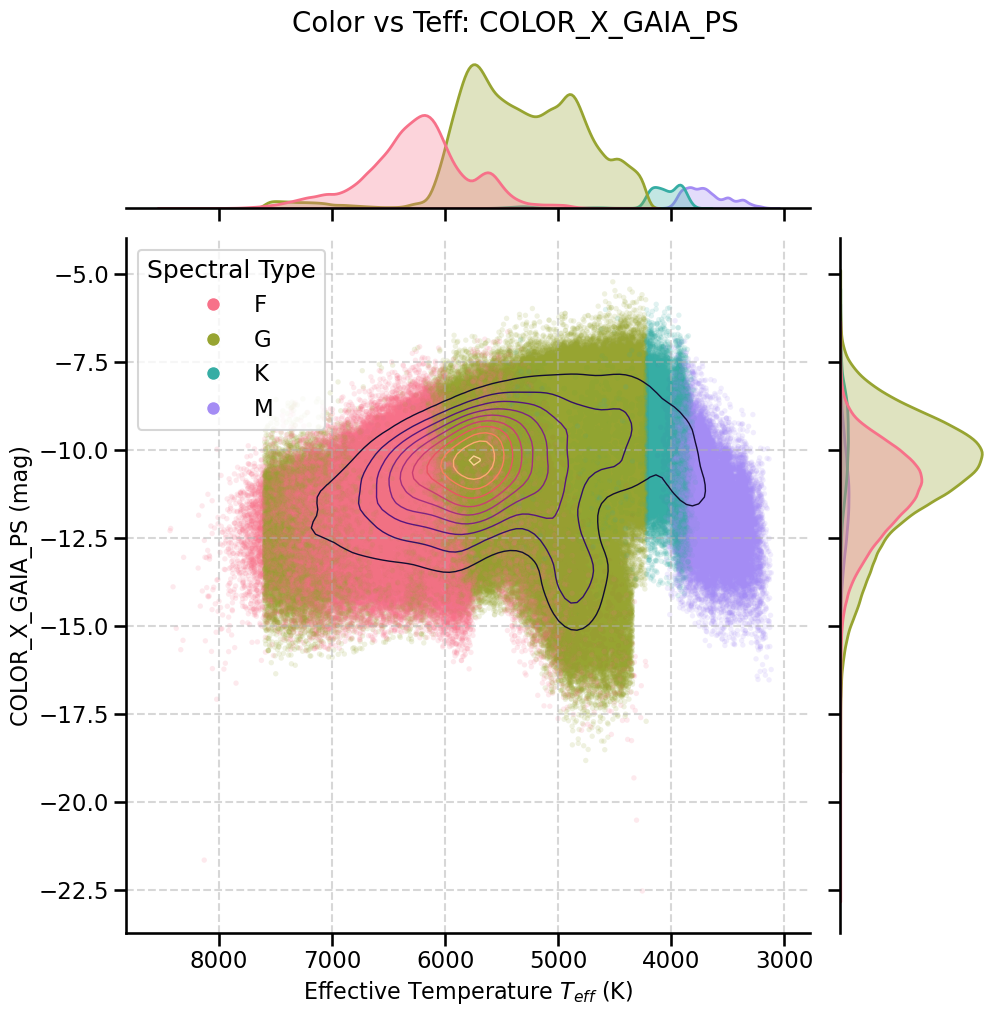

In [16]:
# Settings for the plots
GRANULARITY_KNOB = 12    # Increase for more detail (more lines), Decrease for smoother look
CONTOUR_COLORMAP = 'magma' # Try: 'viridis', 'plasma', 'inferno', 'magma', 'cividis'

# Loop through all colors and generate the new plots
for color_name in color_combinations.keys():
    if color_name in df.columns:
        print(f"Generating improved plot for {color_name}...")
        save_name = RESULTS_DIR / f"{color_name}_vs_Teff_improved.png"
        
        # Clear memory before plotting
        plt.close('all') 
        
        plot_color_vs_teff_improved(
            df, 
            color_name, 
            save_path=save_name, 
            contour_levels=GRANULARITY_KNOB, 
            contour_cmap=CONTOUR_COLORMAP
        )
        
        # Uncomment below if you want to see one example inline immediately
        # plt.show()
        # break

## Phase 5: Batch Processing

Looping through all colors and saving results.

In [10]:
"""for color_name in color_combinations.keys():
    if color_name in df.columns:
        print(f"Generating plot for {color_name}...")
        save_name = RESULTS_DIR / f"{color_name}_vs_Teff_consolidated.png"
        plt.close('all') # Clear memory
        plot_color_vs_teff(df, color_name, save_path=save_name)
        # plt.show() # Uncomment to show all plots in notebook"""

'for color_name in color_combinations.keys():\n    if color_name in df.columns:\n        print(f"Generating plot for {color_name}...")\n        save_name = RESULTS_DIR / f"{color_name}_vs_Teff_consolidated.png"\n        plt.close(\'all\') # Clear memory\n        plot_color_vs_teff(df, color_name, save_path=save_name)\n        # plt.show() # Uncomment to show all plots in notebook'